# Conformer alignment & comparison

Align and compare conformers using Kabsch alignment: `ConformerOptimizer`, `visualize_comparison`, and pairplots. Fragmentation: **03_fragmentation.ipynb**. Data/pocket viz: **01_visualize_data_and_pocket.ipynb**.

In [13]:
import copy
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import TorsionFingerprints
from tqdm import tqdm

from sigmadock.chem.ligalign import ConformerOptimizer, visualize_comparison

warnings.filterwarnings("ignore")

# Prefer env; see notebooks/README.md
DATA_DIR = Path(os.environ.get("SIGMADOCK_DATA_DIR", "../data")).resolve()
ASTEX_DATASET = DATA_DIR / "posebusters_paper/astex_diverse_set/"
ASTEX_IDXS = ASTEX_DATASET.parent / "astex_diverse_set_ids.txt"
POSEBUSTERS_DATASET = DATA_DIR / "posebusters_paper/posebusters_benchmark_set/"
POSEBUSTERS_IDXS = POSEBUSTERS_DATASET.parent / "posebusters_benchmark_set_ids.txt"
astex_df = pd.read_csv(ASTEX_IDXS, sep="\t", header=None) if ASTEX_IDXS.exists() else pd.DataFrame()
posebusters_df = pd.read_csv(POSEBUSTERS_IDXS, sep="\t", header=None) if POSEBUSTERS_IDXS.exists() else pd.DataFrame()

# NOTE: Pick one to test
df_of_choice = astex_df
max_mols_to_parse = 100

Assumptions
* We must ensure that the datasets we use follow the criteria!
* We are not parsing hydrogens therefore
    * We do not protonate the PDB
    * We skip hydrogens in the SDF. This requires correct Kekulization though! (bond assignment)
* We assume PDB files are clean. This is not strictly always the case (definitely not) but will suffice for academic proof of concept. 
* We have access to a <PDB_ID>_<LIG_ID>_pocket.pdb file which allows us to do pocket-based docking. 

Checklist 
* Make sure we select / sample the correct ligand from the multi-sdf file. Sometimes there are multiple ligand sdfs -> multiple chains. 

## Alignment (Kabsch)

In [15]:
# Plot statistics relating all_rmsds, all_mol_weights, all_num_tor_bonds
def _diag_kde_with_stats(x, color, label, **kwargs) -> None:  # noqa: ANN001, ANN003
    """Custom diagonal plot: KDE + mean/std as text annotation."""
    ax = kwargs.pop("ax", plt.gca())
    sns.kdeplot(x, color=color, fill=True, ax=ax, **kwargs)

    mean = np.mean(x)
    std = np.std(x, ddof=1)
    textstr = f"μ={mean:.3g}\nσ={std:.3g}"

    # place text in the top-right corner of the plot
    ax.text(
        0.95, 0.95, textstr,
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=9,
        bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "alpha": 0.6, "edgecolor": "none"}
    )

def plot_statistics(rmsds, mol_weights, num_tor_bonds, outpath: str | Path | None = None):  # noqa
    df = pd.DataFrame(
        {
            "RMSD (Å)": rmsds,
            "Molecular Weight (Da)": mol_weights,
            "Number of Torsion Bonds": num_tor_bonds,
        }
    )
    g = sns.pairplot(df, diag_kind="kde")
    # overwrite diagonals with custom function
    for i, var in enumerate(df.columns):
        ax = g.axes[i, i]
        _diag_kde_with_stats(df[var].values, color="C0", label=var, ax=ax)

    if outpath is not None:
        plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()
    
    # Also save the kde for RMSD only
    plt.figure()
    _diag_kde_with_stats(df["RMSD (Å)"].values, color="C0", label="RMSD (Å)")
    if outpath is not None:
        outpath = Path(outpath)
        plt.xlabel("RMSD (Å)")
        plt.savefig(outpath.parent / f"{outpath.stem}_RMSD_only{outpath.suffix}", dpi=300, bbox_inches="tight")
    
# For maximal alignment (slowest but most accurate)
RMSD_TOL = 0.0

### Three Independent Alignment Attempts 

100%|██████████| 85/85 [00:57<00:00,  1.47it/s]


RMSD Statistics:
Min: 0.046, Max: 0.939, Mean: 0.202, Std: 0.162
Molecular Weight Statistics:
Min: 147.066, Max: 575.245, Mean: 325.254, Std: 97.845
Number of Torsion Bonds Statistics:
Min: 0, Max: 12, Mean: 5.176, Std: 3.045


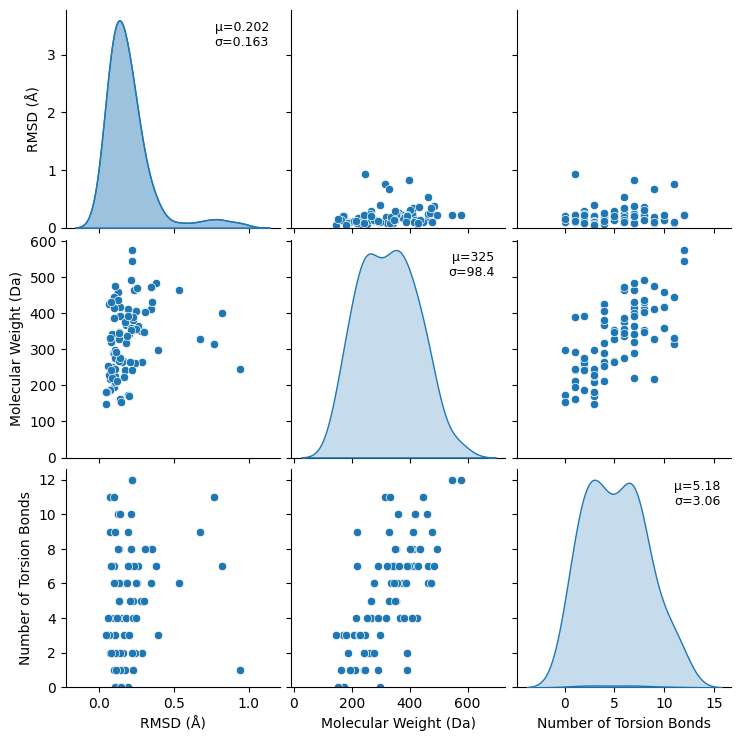

Text(0, 0.5, 'Count')

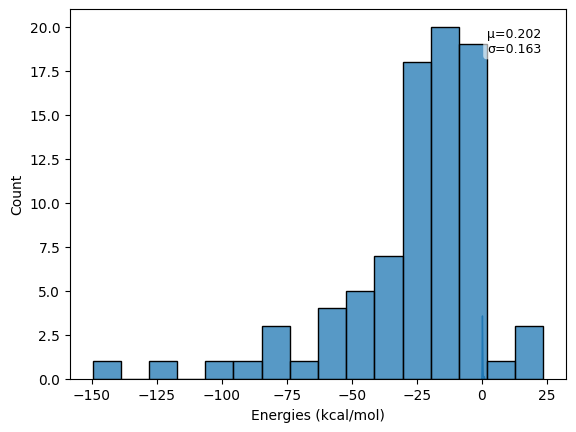

In [17]:
# Three alignment attempts
all_rmsds = []
all_mol_weights = []
all_num_tor_bonds = []
all_energies = []

max_tries = 5
for idx in tqdm(range(len(df_of_choice))):
    pdb_lig_id = df_of_choice.iloc[idx].item().upper()
    ligand_files = (
        ASTEX_DATASET / pdb_lig_id / (pdb_lig_id + "_ligands.sdf")
    )  # Reference ligand(s). Sometimes more than 1 due to chains.
    pdb_file = ASTEX_DATASET / pdb_lig_id / (pdb_lig_id + "_protein.pdb")

    # Parse SDF
    supp = Chem.SDMolSupplier(str(ligand_files), removeHs=False)
    mol = next(supp)
    smiles = Chem.MolToSmiles(mol)

    # Configure optimization
    optimizer = ConformerOptimizer(
        mol,
        tries=max_tries,
        popsize=10,
        maxiter=50,
        tolerance=RMSD_TOL,
        ignore_conjugated=False,
    )

    # Run optimization
    optimized_mol, rmsd, energies, pb_checks = optimizer.optimize_torsions()
    all_rmsds.append(rmsd)
    all_energies.append(energies)
    all_mol_weights.append(Chem.rdMolDescriptors.CalcExactMolWt(mol))
    all_num_tor_bonds.append(len(TorsionFingerprints.CalculateTorsionLists(mol)[0]))

    if idx >= max_mols_to_parse:
        break

# RMSD min max std mean of all metrics (rmsd, weight, num tor bonds)
print("RMSD Statistics:")
print(
    f"Min: {np.min(all_rmsds):.3f}, Max: {np.max(all_rmsds):.3f}, Mean: {np.mean(all_rmsds):.3f}, Std: {np.std(all_rmsds):.3f}"
)

print("Molecular Weight Statistics:")
print(
    f"Min: {np.min(all_mol_weights):.3f}, Max: {np.max(all_mol_weights):.3f}, Mean: {np.mean(all_mol_weights):.3f}, Std: {np.std(all_mol_weights):.3f}"
)

print("Number of Torsion Bonds Statistics:")
print(
    f"Min: {np.min(all_num_tor_bonds)}, Max: {np.max(all_num_tor_bonds)}, Mean: {np.mean(all_num_tor_bonds):.3f}, Std: {np.std(all_num_tor_bonds):.3f}"
)

plot_statistics(
    all_rmsds, all_mol_weights, all_num_tor_bonds, 
)
sns.histplot(all_energies)
plt.xlabel("Energies (kcal/mol)")
plt.ylabel("Count")

### Single Alignment Attempt

100%|██████████| 85/85 [00:22<00:00,  3.74it/s]


RMSD Statistics:
Min: 0.047, Max: 1.461, Mean: 0.390, Std: 0.343
Molecular Weight Statistics:
Min: 147.066, Max: 575.245, Mean: 325.254, Std: 97.845
Number of Torsion Bonds Statistics:
Min: 0, Max: 12, Mean: 5.176, Std: 3.045


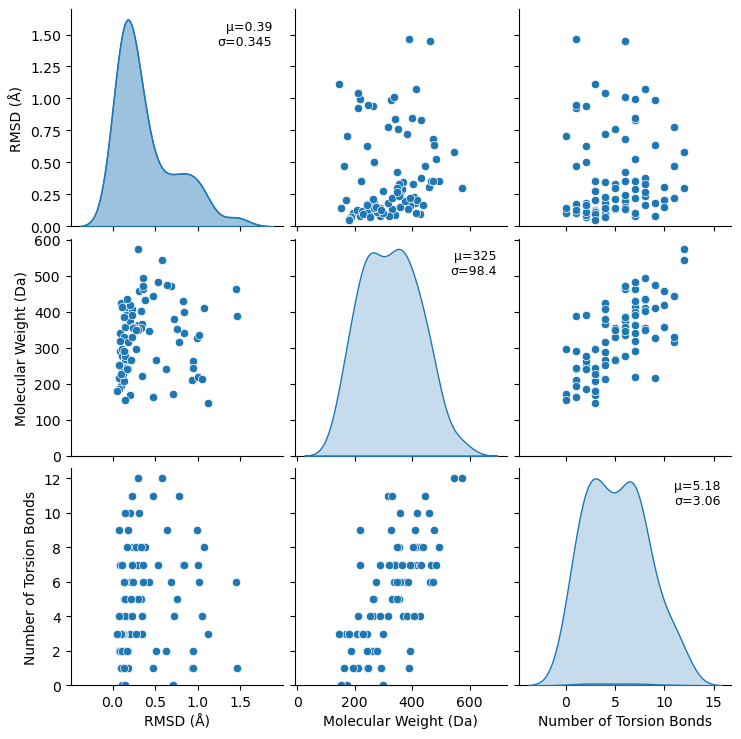

Text(0, 0.5, 'Count')

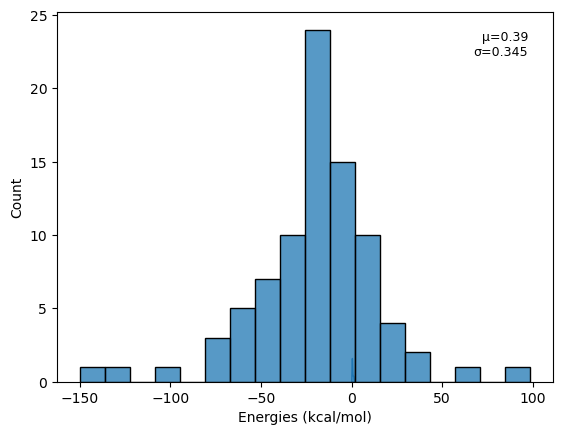

In [8]:
all_rmsds = []
all_mol_weights = []
all_num_tor_bonds = []
all_energies = []

max_tries = 1
for idx in tqdm(range(len(df_of_choice))):
    pdb_lig_id = df_of_choice.iloc[idx].item().upper()
    ligand_files = (
        ASTEX_DATASET / pdb_lig_id / (pdb_lig_id + "_ligands.sdf")
    )  # Reference ligand(s). Sometimes more than 1 due to chains.
    pdb_file = ASTEX_DATASET / pdb_lig_id / (pdb_lig_id + "_protein.pdb")

    # Parse SDF
    supp = Chem.SDMolSupplier(str(ligand_files), removeHs=False)
    mol = next(supp)
    smiles = Chem.MolToSmiles(mol)

    # Configure optimization
    optimizer = ConformerOptimizer(
        mol,
        tries=max_tries,
        popsize=10,
        maxiter=50,
        tolerance=RMSD_TOL,
        ignore_conjugated=False,
    )

    # Run optimization
    optimized_mol, rmsd, energies, pb_checks = optimizer.optimize_torsions()
    all_rmsds.append(rmsd)
    all_energies.append(energies)
    all_mol_weights.append(Chem.rdMolDescriptors.CalcExactMolWt(mol))
    all_num_tor_bonds.append(len(TorsionFingerprints.CalculateTorsionLists(mol)[0]))

    if idx >= max_mols_to_parse:
        break

# RMSD min max std mean of all metrics (rmsd, weight, num tor bonds)
print("RMSD Statistics:")
print(
    f"Min: {np.min(all_rmsds):.3f}, Max: {np.max(all_rmsds):.3f}, Mean: {np.mean(all_rmsds):.3f}, Std: {np.std(all_rmsds):.3f}"
)

print("Molecular Weight Statistics:")
print(
    f"Min: {np.min(all_mol_weights):.3f}, Max: {np.max(all_mol_weights):.3f}, Mean: {np.mean(all_mol_weights):.3f}, Std: {np.std(all_mol_weights):.3f}"
)

print("Number of Torsion Bonds Statistics:")
print(
    f"Min: {np.min(all_num_tor_bonds)}, Max: {np.max(all_num_tor_bonds)}, Mean: {np.mean(all_num_tor_bonds):.3f}, Std: {np.std(all_num_tor_bonds):.3f}"
)

plot_statistics(
    all_rmsds, all_mol_weights, all_num_tor_bonds, 
)
sns.histplot(all_energies)
plt.xlabel("Energies (kcal/mol)")
plt.ylabel("Count")

# Minimization

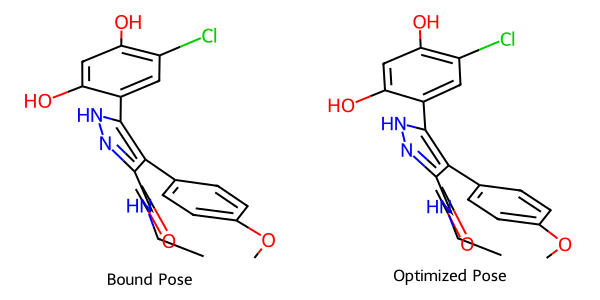

0.14293938196893566 -5.2237436570067075 True


In [18]:
optimizer = ConformerOptimizer(
    copy.deepcopy(mol),
    tries=5,
    popsize=10,
    maxiter=50,
    tolerance=0.5,
    ring_matching = False,
    ignore_conjugated = False,
)

# Run optimization TF
optimized_mol, rmsd, energy_change, pb_val = optimizer.optimize_torsions()
display(visualize_comparison(optimizer.ref_mol, optimized_mol))
print(rmsd, energy_change, pb_val)